## 문제 1. MSE (mean squared error) 만들기
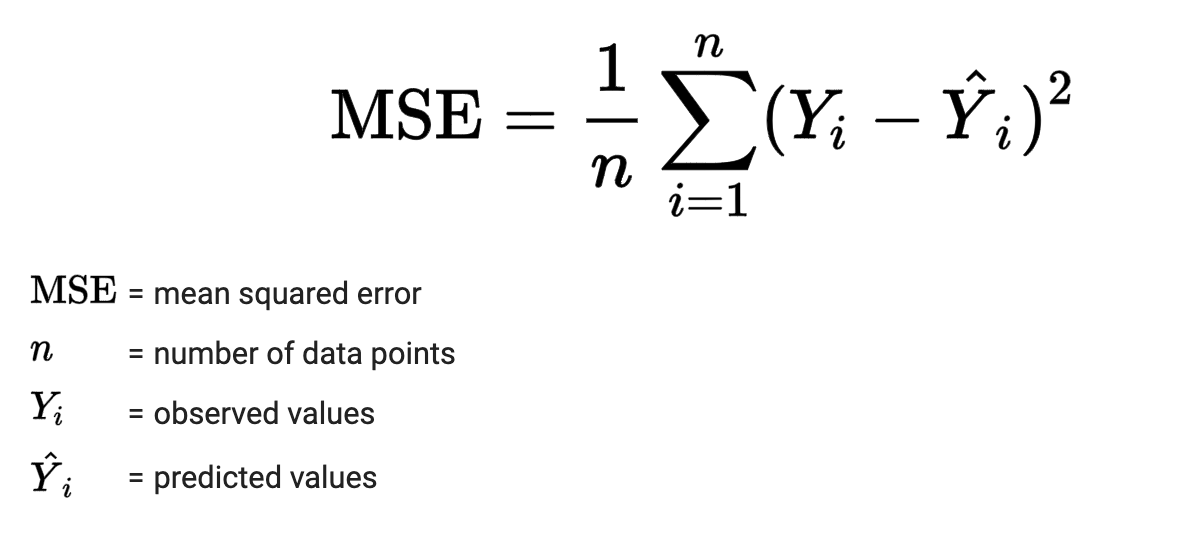

y_observed, y_predicted에 대해 MSE를 구해봅시다. 위에 첨부한 식을 사용하세요.

(1) from scratch로 직접 제작해서 구하기

(2) 패키지로 구하기 (힌트 : from sklearn.metrics import ~~)

두 값이 0.03692222222222222로 같은지 확인해봅시다.

In [18]:
pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 39.2 MB/s  0:00:00 45.5 MB/s eta 0:00:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 37.9 MB/s  0:00:00 36.9 MB/s eta 0:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn]0m 3/4 [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [15]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

In [16]:
y_observed = [0.06, 0.8, 0.11, 0.65, 0.34, 0.5, 0.74, 0.62, 0.4]
y_predicted = [0.05, 0.9, 0.1, 0.6, 0.2, 0.8, 0.3, 0.7, 0.5]

In [19]:
n = len(y_observed)
total = 0

for i in range(n):
    diff = y_observed[i] - y_predicted[i]
    total = total + (diff ** 2)

mse = total/n
print("From scratch MSE: ", mse)

from sklearn.metrics import mean_squared_error
mSe = mean_squared_error(y_observed, y_predicted)
print("Sklearn MSE: ", mSe)

From scratch MSE:  0.036922222222222224
Sklearn MSE:  0.03692222222222222


## 문제 2. 우리가 만든 일차함수 맞히기 파이프라인에서 시작해봅시다.

1. 평균 제곱 오차(MSE) 외에 다른 손실 함수를 사용해보고 결과를 비교하세요.
2. 옵티마이저를 SGD 외에 다른 걸 사용해보세요. 구글에 tensorflow optimizer라고 검색하면 많이 나옵니다.
3. 실제 부동산 데이터셋(예: Kaggle의 집값 데이터)을 찾아 실제 데이터를 이용한 모델을 구현해보세요.

In [4]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [ ]:
model = keras.Sequential([keras.layers.Dense(units=1, input_shape=[1])])

xs = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=float)
ys = np.array([0.06, 0.8, 0.11, 0.65, 0.34, 0.5, 0.74, 0.62, 0.4], dtype=float)

# mse

model.compile(optimizer= 'sgd', loss = 'mse')
model.fit(xs, ys, epochs=500)
y_pred = model.predict(x_train)
n = len(y_train)
for i in range(n):
    diff = y_train[i] - y_pred[i][0]
    total = total + (diff ** 2)
mse = total/n
print ("MSE: ", mse)

# mse + adam

model.compile(optimizer= 'adam', loss = 'mse')
model.fit(xs, ys, epochs=500)
y_pred = model.predict(x_train)
n = len(y_train)
for i in range(n):
    diff = y_train[i] - y_pred[i][0]
    total = total + (diff ** 2)
mse = total/n
print ("MSE + ADAM : ", mse)

# MAE + SGD

model.compile(optimizer= 'sgd', loss = 'mae')
model.fit(xs, ys, epochs=500)
y_pred = model.predict(x_train)
n = len(y_train)
for i in range(n):
    diff = y_train[i] - y_pred[i][0]
    total = total + abs(diff)
mae = total/n
print ("MAE: ", mae)

In [28]:
import pandas as pd

df = pd.read_csv('nyc_housing_base.csv')

df = df.dropna(subset=['bldgarea', 'sale_price'])
df = df[df['sale_price']>0]

x_real = np.array(df['bldgarea'], dtype=float)
y_real = np.array(df['sale_price'], dtype=float)

model = keras.Sequential([keras.layers.Dense(units=1, input_shape=[1])])

model.compile(optimizer= 'adam', loss = 'mse')

print ('x_real: ',x_real/10000)
print ('y_real: ',y_real/1000000)

x_real:  [0.6875 0.781  0.6152 ... 0.22   0.1458 0.375 ]
y_real:  [0.28     2.       3.4      ... 1.2      0.8      0.999999]


In [29]:
model.fit(x_real/10000, y_real/1000000, epochs=500)
y_pred = model.predict(x_real/10000)*1000000
n1 = len(y_real)
for i in range(n1):
    diff1 = y_real[i] - y_pred[i][0]
    total1 = total + (diff ** 2)
mse1 = total1/n1
print ("실제 NYC 부동산 데이터 MSE: ", mse1)

Epoch 1/500
1077/1077 ━━━━━━━━━━━━━━━━━━━━ 1s 919us/step - loss: 63.0440
Epoch 2/500
1077/1077 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 3.3056
Epoch 3/500
1077/1077 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 1.5489
Epoch 4/500
1077/1077 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.5331
Epoch 5/500
1077/1077 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.5318
Epoch 6/500
1077/1077 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1.5320
Epoch 7/500
1077/1077 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.5321
Epoch 8/500
1077/1077 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1.5328
Epoch 9/500
1077/1077 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.5331
Epoch 10/500
1077/1077 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1.5331
Epoch 11/500
1077/1077 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.5341
Epoch 12/500
1077/1077 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.5341
Epoch 13/500
1077/1077 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 1.5343
Epoch 14/500
1077/1077 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.5338
Epoch 15/500